# Forest Cover Prediction

## Objective

Build a system that can predict the type of forest cover using analysis data for a 30m x 30m patch of land in the forest.

## 1. Import Libraries

In [1]:
# Basic libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Data preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Evaluation metrics
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,classification_report,confusion_matrix)

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

## 2. Load Dataset

In [2]:
# Loading dataset
df = pd.read_csv(r"C:\Users\THRISHA\OneDrive\Desktop\forest_cover_prediction\train.csv")
df

,Id,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,...,Soil_Type32,Soil_Type33,Soil_Type34,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,Cover_Type
0,1,2596,51,3,258,0,510,221,232,148,...,0,0,0,0,0,0,0,0,0,5
1,2,2590,56,2,212,-6,390,220,235,151,...,0,0,0,0,0,0,0,0,0,5
2,3,2804,139,9,268,65,3180,234,238,135,...,0,0,0,0,0,0,0,0,0,2
3,4,2785,155,18,242,118,3090,238,238,122,...,0,0,0,0,0,0,0,0,0,2
4,5,2595,45,2,153,-1,391,220,234,150,...,0,0,0,0,0,0,0,0,0,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15115,15116,2607,243,23,258,7,660,170,251,214,...,0,0,0,0,0,0,0,0,0,3
15116,15117,2603,121,19,633,195,618,249,221,91,...,0,0,0,0,0,0,0,0,0,3
15117,15118,2492,134,25,365,117,335,250,220,83,...,0,0,0,0,0,0,0,0,0,3
15118,15119,2487,167,28,218,101,242,229,237,119,...,0,0,0,0,0,0,0,0,0,3


The target variable is **Cover_Type**, which represents one of the seven forest cover classes:

1 → Spruce/Fir  
2 → Lodgepole Pine  
3 → Ponderosa Pine  
4 → Cottonwood/Willow  
5 → Aspen  
6 → Douglas-fir  
7 → Krummholz

## 3. Dataset Overview

In [3]:
# Shape of the dataset
print("Dataset Shape:", df.shape)

Dataset Shape: (15120, 56)


In [4]:
# Dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15120 entries, 0 to 15119
Data columns (total 56 columns):
 #   Column                              Non-Null Count  Dtype
---  ------                              --------------  -----
 0   Id                                  15120 non-null  int64
 1   Elevation                           15120 non-null  int64
 2   Aspect                              15120 non-null  int64
 3   Slope                               15120 non-null  int64
 4   Horizontal_Distance_To_Hydrology    15120 non-null  int64
 5   Vertical_Distance_To_Hydrology      15120 non-null  int64
 6   Horizontal_Distance_To_Roadways     15120 non-null  int64
 7   Hillshade_9am                       15120 non-null  int64
 8   Hillshade_Noon                      15120 non-null  int64
 9   Hillshade_3pm                       15120 non-null  int64
 10  Horizontal_Distance_To_Fire_Points  15120 non-null  int64
 11  Wilderness_Area1                    15120 non-null  int64
 12  Wild

In [5]:
# Statistical summary
df.describe()

,Id,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,...,Soil_Type32,Soil_Type33,Soil_Type34,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,Cover_Type
count,15120.00000,15120.000000,15120.000000,15120.000000,15120.000000,15120.000000,15120.000000,15120.000000,15120.000000,15120.000000,...,15120.000000,15120.000000,15120.000000,15120.000000,15120.000000,15120.000000,15120.000000,15120.000000,15120.000000,15120.000000
mean,7560.50000,2749.322553,156.676653,16.501587,227.195701,51.076521,1714.023214,212.704299,218.965608,135.091997,...,0.045635,0.040741,0.001455,0.006746,0.000661,0.002249,0.048148,0.043452,0.030357,4.000000
std,4364.91237,417.678187,110.085801,8.453927,210.075296,61.239406,1325.066358,30.561287,22.801966,45.895189,...,0.208699,0.197696,0.038118,0.081859,0.025710,0.047368,0.214086,0.203880,0.171574,2.000066
min,1.00000,1863.000000,0.000000,0.000000,0.000000,-146.000000,0.000000,0.000000,99.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,3780.75000,2376.000000,65.000000,10.000000,67.000000,5.000000,764.000000,196.000000,207.000000,106.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
50%,7560.50000,2752.000000,126.000000,15.000000,180.000000,32.000000,1316.000000,220.000000,223.000000,138.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000
75%,11340.25000,3104.000000,261.000000,22.000000,330.000000,79.000000,2270.000000,235.000000,235.000000,167.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000
max,15120.00000,3849.000000,360.000000,52.000000,1343.000000,554.000000,6890.000000,254.000000,254.000000,248.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,7.000000


In [6]:
# Distribution of target classes
print(df['Cover_Type'].value_counts())

Cover_Type
5    2160
2    2160
1    2160
7    2160
3    2160
6    2160
4    2160
Name: count, dtype: int64


In [7]:
# Check missing values
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
Id                                    0
Elevation                             0
Aspect                                0
Slope                                 0
Horizontal_Distance_To_Hydrology      0
Vertical_Distance_To_Hydrology        0
Horizontal_Distance_To_Roadways       0
Hillshade_9am                         0
Hillshade_Noon                        0
Hillshade_3pm                         0
Horizontal_Distance_To_Fire_Points    0
Wilderness_Area1                      0
Wilderness_Area2                      0
Wilderness_Area3                      0
Wilderness_Area4                      0
Soil_Type1                            0
Soil_Type2                            0
Soil_Type3                            0
Soil_Type4                            0
Soil_Type5                            0
Soil_Type6                            0
Soil_Type7                            0
Soil_Type8                            0
Soil_Type9                            0
Soil_Type10             

In [8]:
# Check duplicate rows
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


## 4. Data Preprocessing

In [9]:
# Removing ID column
df = df.drop('Id', axis=1)

df.head()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type32,Soil_Type33,Soil_Type34,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,Cover_Type
0,2596,51,3,258,0,510,221,232,148,6279,...,0,0,0,0,0,0,0,0,0,5
1,2590,56,2,212,-6,390,220,235,151,6225,...,0,0,0,0,0,0,0,0,0,5
2,2804,139,9,268,65,3180,234,238,135,6121,...,0,0,0,0,0,0,0,0,0,2
3,2785,155,18,242,118,3090,238,238,122,6211,...,0,0,0,0,0,0,0,0,0,2
4,2595,45,2,153,-1,391,220,234,150,6172,...,0,0,0,0,0,0,0,0,0,5


## 5. Exploratory Data Analysis (EDA)

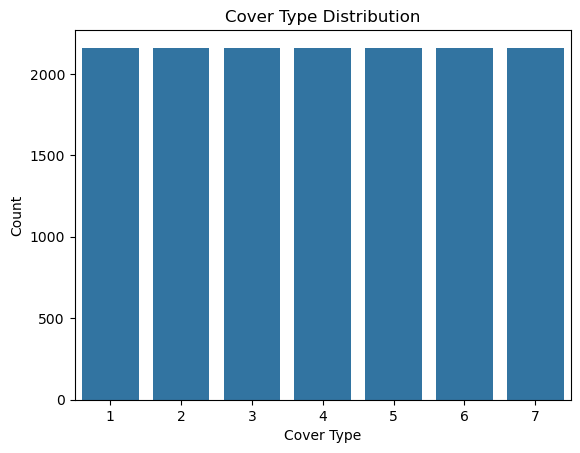

In [10]:
# Distribution of target classes
sns.countplot(x='Cover_Type', data=df)
plt.title('Cover Type Distribution')
plt.xlabel('Cover Type')
plt.ylabel('Count')
plt.show()

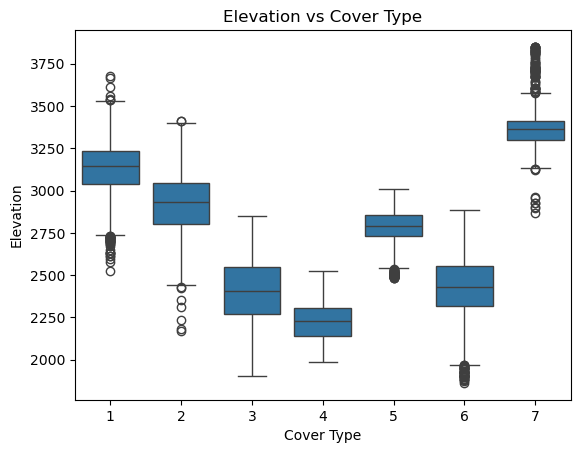

In [11]:
# Elevation distribution across cover types
sns.boxplot(x='Cover_Type', y='Elevation', data=df)
plt.title('Elevation vs Cover Type')
plt.xlabel('Cover Type')
plt.ylabel('Elevation')
plt.show()

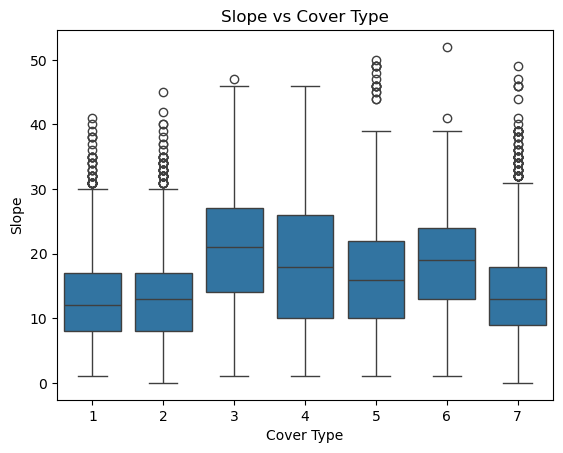

In [12]:
# Slope distribution across cover types
sns.boxplot(x='Cover_Type', y='Slope', data=df)
plt.title('Slope vs Cover Type')
plt.xlabel('Cover Type')
plt.ylabel('Slope')

plt.show()

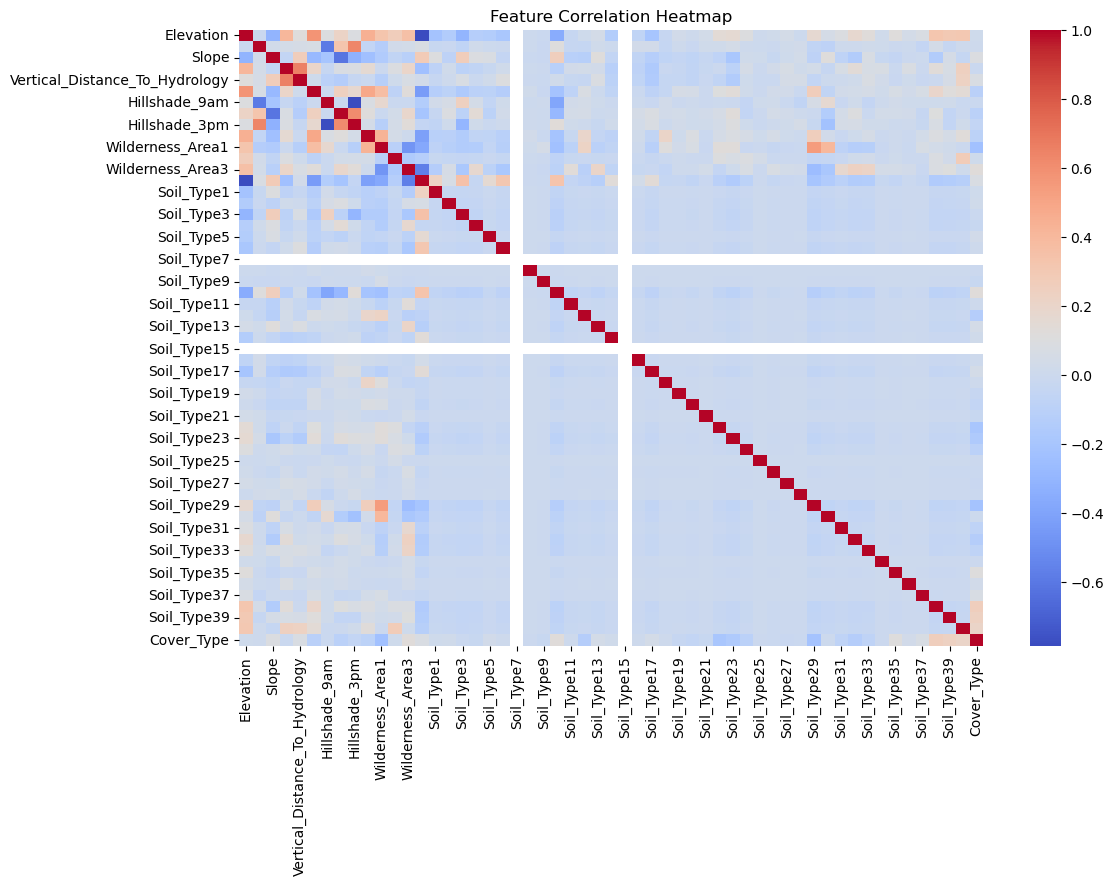

In [13]:
# Correlation heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

## 6. Feature and Target Separation

In [14]:
# Separate input features and target variable
X = df.drop('Cover_Type', axis=1)
y = df['Cover_Type']
print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (15120, 54)
Target Shape: (15120,)


## 7. Train-Test Split

In [15]:
# Split dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
print("X_train Shape:", X_train.shape)
print("X_test Shape :", X_test.shape)
print("y_train Shape:", y_train.shape)
print("y_test Shape :", y_test.shape)

X_train Shape: (12096, 54)
X_test Shape : (3024, 54)
y_train Shape: (12096,)
y_test Shape : (3024,)


## 8. Feature Scaling

In [16]:
# Standardize feature values
scaler = StandardScaler()

# Scaling training and testing features
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Scaled training data shape:", X_train_scaled.shape)
print("Scaled testing data shape:", X_test_scaled.shape)

Scaled training data shape: (12096, 54)
Scaled testing data shape: (3024, 54)


## 9. Model Training and Evaluation

### 9.1 Logistic Regression

In [17]:
# Initializing Logistic Regression model
lr = LogisticRegression(random_state=42, max_iter=1000)

# Training the model
lr.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [18]:
# Predictions on test data
y_pred_lr = lr.predict(X_test_scaled)

In [19]:
# Evaluation metrics
lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_precision = precision_score(y_test, y_pred_lr, average='weighted')
lr_recall = recall_score(y_test, y_pred_lr, average='weighted')
lr_f1 = f1_score(y_test, y_pred_lr, average='weighted')

print("Accuracy :", lr_accuracy)
print("Precision:", lr_precision)
print("Recall   :", lr_recall)
print("F1 Score :", lr_f1)

Accuracy : 0.6917989417989417
Precision: 0.6888153430559499
Recall   : 0.6917989417989417
F1 Score : 0.6890684424121714


In [20]:
# Classification report
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           1       0.64      0.68      0.66       432
           2       0.58      0.50      0.53       432
           3       0.59      0.52      0.56       432
           4       0.82      0.88      0.85       432
           5       0.72      0.75      0.73       432
           6       0.58      0.65      0.61       432
           7       0.88      0.87      0.88       432

    accuracy                           0.69      3024
   macro avg       0.69      0.69      0.69      3024
weighted avg       0.69      0.69      0.69      3024



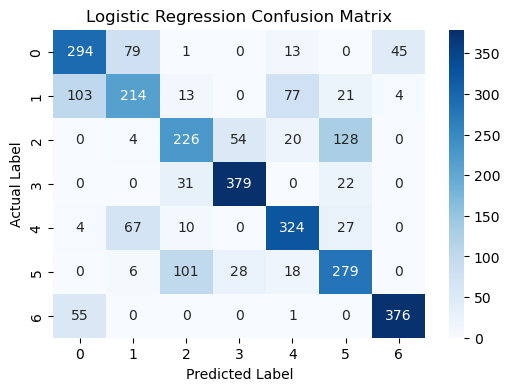

In [21]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred_lr)

# Visualizing confusion matrix
plt.figure(figsize=(6,4))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()

### 9.2 Decision Tree Classifier

In [22]:
# Initializing Decision Tree model
dt = DecisionTreeClassifier(random_state=42)

# Training the model
dt.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [23]:
# Predictions on test data
y_pred_dt = dt.predict(X_test)

In [24]:
# Evaluation metrics
dt_accuracy = accuracy_score(y_test, y_pred_dt)
dt_precision = precision_score(y_test, y_pred_dt, average='weighted')
dt_recall = recall_score(y_test, y_pred_dt, average='weighted')
dt_f1 = f1_score(y_test, y_pred_dt, average='weighted')

print("Accuracy :", dt_accuracy)
print("Precision:", dt_precision)
print("Recall   :", dt_recall)
print("F1 Score :", dt_f1)

Accuracy : 0.7903439153439153
Precision: 0.7896198846252411
Recall   : 0.7903439153439153
F1 Score : 0.789819304916986


In [25]:
# Classification report
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           1       0.69      0.65      0.67       432
           2       0.62      0.62      0.62       432
           3       0.72      0.75      0.73       432
           4       0.93      0.92      0.92       432
           5       0.86      0.89      0.88       432
           6       0.78      0.78      0.78       432
           7       0.92      0.92      0.92       432

    accuracy                           0.79      3024
   macro avg       0.79      0.79      0.79      3024
weighted avg       0.79      0.79      0.79      3024



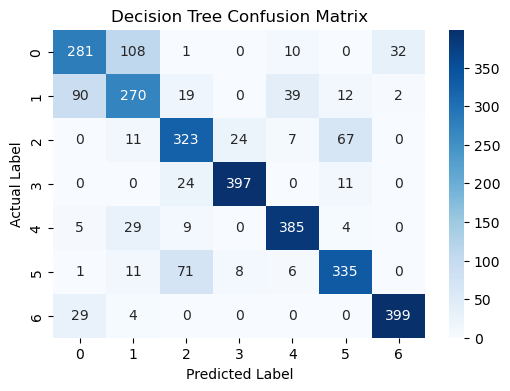

In [26]:
# Confusion matrix 
cm = confusion_matrix(y_test, y_pred_dt)

# Visualizing Confusion matrix
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Decision Tree Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()

### 9.3 Random Forest Classifier

In [27]:
# Initializing Random Forest model
rf = RandomForestClassifier(n_estimators=100,random_state=42)

# Training the model
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [28]:
# Predictions on test data
y_pred_rf = rf.predict(X_test)

In [29]:
# Evaluation metrics
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf, average='weighted')
rf_recall = recall_score(y_test, y_pred_rf, average='weighted')
rf_f1 = f1_score(y_test, y_pred_rf, average='weighted')

print("Accuracy :", rf_accuracy)
print("Precision:", rf_precision)
print("Recall   :", rf_recall)
print("F1 Score :", rf_f1)

Accuracy : 0.8551587301587301
Precision: 0.8521850342234593
Recall   : 0.8551587301587301
F1 Score : 0.8523930955921962


In [30]:
# Classification report
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           1       0.78      0.77      0.77       432
           2       0.78      0.65      0.71       432
           3       0.83      0.81      0.82       432
           4       0.93      0.97      0.95       432
           5       0.88      0.94      0.91       432
           6       0.83      0.88      0.85       432
           7       0.94      0.97      0.95       432

    accuracy                           0.86      3024
   macro avg       0.85      0.86      0.85      3024
weighted avg       0.85      0.86      0.85      3024



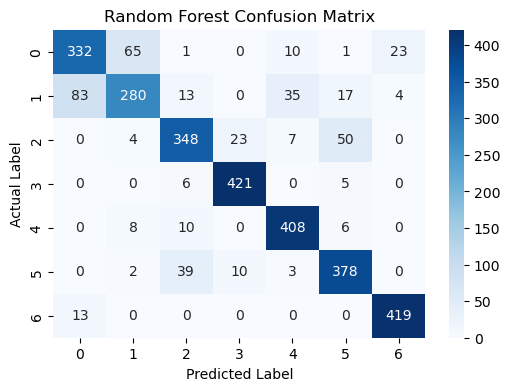

In [31]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred_rf)

# Visualizing Confusion matrix
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()

### 9.4 Support Vector Classifier (SVC)

In [32]:
# Initializing SVC model
svc_model = SVC(random_state=42)

# Training the model
svc_model.fit(X_train_scaled, y_train)

SVC(random_state=42)

In [33]:
# Predictions using SVC model
y_pred_svc = svc_model.predict(X_test_scaled)

In [34]:
# Evaluation metrics
svc_accuracy = accuracy_score(y_test, y_pred_svc)
svc_precision = precision_score(y_test, y_pred_svc, average='weighted')
svc_recall = recall_score(y_test, y_pred_svc, average='weighted')
svc_f1 = f1_score(y_test, y_pred_svc, average='weighted')

print("Accuracy :", svc_accuracy)
print("Precision:", svc_precision)
print("Recall   :", svc_recall)
print("F1 Score :", svc_f1)

Accuracy : 0.7271825396825397
Precision: 0.7245378322726129
Recall   : 0.7271825396825397
F1 Score : 0.7241355063797952


In [35]:
# Classification report
print(classification_report(y_test, y_pred_svc))

              precision    recall  f1-score   support

           1       0.65      0.69      0.67       432
           2       0.62      0.54      0.58       432
           3       0.66      0.59      0.63       432
           4       0.82      0.96      0.88       432
           5       0.76      0.79      0.77       432
           6       0.64      0.66      0.65       432
           7       0.92      0.86      0.89       432

    accuracy                           0.73      3024
   macro avg       0.72      0.73      0.72      3024
weighted avg       0.72      0.73      0.72      3024



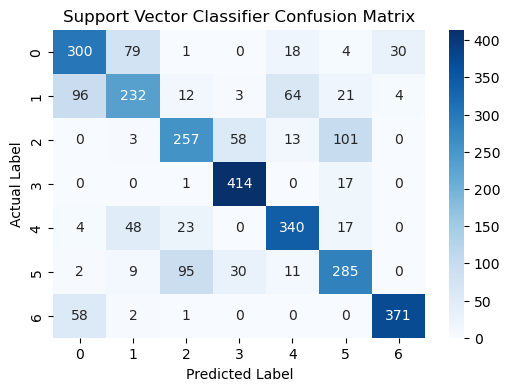

In [36]:
# Confusion Matrix 
cm = confusion_matrix(y_test, y_pred_svc)

# Visualizing Confusion matrix
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Support Vector Classifier Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()

## 10. Model Comparison

In [37]:
# Model Comparison Table
comparison = pd.DataFrame({'Model': ['Logistic Regression','Decision Tree Classifier','Random Forest Classifier','Support Vector Classifier'],
                           'Accuracy': [0.6918, 0.7903, 0.8552, 0.7272],'Precision': [0.6888, 0.7896, 0.8522, 0.7245],
                           'Recall': [0.6918, 0.7903, 0.8552, 0.7272],'F1 Score': [0.6891, 0.7898, 0.8524, 0.7241]})
comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.6918,0.6888,0.6918,0.6891
1,Decision Tree Classifier,0.7903,0.7896,0.7903,0.7898
2,Random Forest Classifier,0.8552,0.8522,0.8552,0.8524
3,Support Vector Classifier,0.7272,0.7245,0.7272,0.7241


## 11. Final Model Selection

Logistic Regression, Decision Tree Classifier, Random Forest Classifier, and Support Vector Classifier (SVC) models were trained and evaluated for forest cover prediction. Among all the models, the Random Forest Classifier achieved the highest accuracy, precision, recall, and F1-score values while correctly classifying the majority of forest cover types across all seven classes.
The model achieved an accuracy of 85.52% and produced the fewest misclassifications compared to the other evaluated models.
Since accurately identifying forest cover types is important for environmental monitoring, land management, and ecological analysis, **the Random Forest Classifier** was selected as the final model for Forest Cover Prediction.

## 12. Prediction

In [38]:
# Taking first sample from dataset
sample_forest = X.iloc[[0]]

# Prediction
prediction = rf.predict(sample_forest)
cover_labels = {1: "Spruce/Fir",2: "Lodgepole Pine",3: "Ponderosa Pine",4: "Cottonwood/Willow",5: "Aspen",6: "Douglas-fir",7: "Krummholz"}
print("Predicted Forest Cover Type:", cover_labels[prediction[0]])

Predicted Forest Cover Type: Aspen


In [39]:
import joblib

# saving model
joblib.dump(rf, "forest_cover_model.pkl")

['forest_cover_model.pkl']

## Feature Importance Analysis

The Forest Cover Type dataset contains 55 input features, including geographical attributes, wilderness area indicators, and soil type variables.

To improve the usability of the Streamlit web application, feature importance analysis was performed using the Random Forest model.

The most influential features were selected for user input in the web application, while default values were assigned to the remaining features during prediction.

This approach reduces user complexity while still utilizing the trained model for forest cover type prediction.

In [42]:
# Feature Importance for streamlit
feature_importance = pd.DataFrame({'Feature': X.columns,'Importance': rf.feature_importances_})
feature_importance.sort_values(by='Importance',ascending=False).head(15)

,Feature,Importance
0,Elevation,0.223352
5,Horizontal_Distance_To_Roadways,0.095550
9,Horizontal_Distance_To_Fire_Points,0.074043
3,Horizontal_Distance_To_Hydrology,0.063634
4,Vertical_Distance_To_Hydrology,0.051701
6,Hillshade_9am,0.050327
1,Aspect,0.049419
8,Hillshade_3pm,0.046229
7,Hillshade_Noon,0.045409
13,Wilderness_Area4,0.037455
